In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [46]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Clean date column
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# Fill missing values
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")

# Check again
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

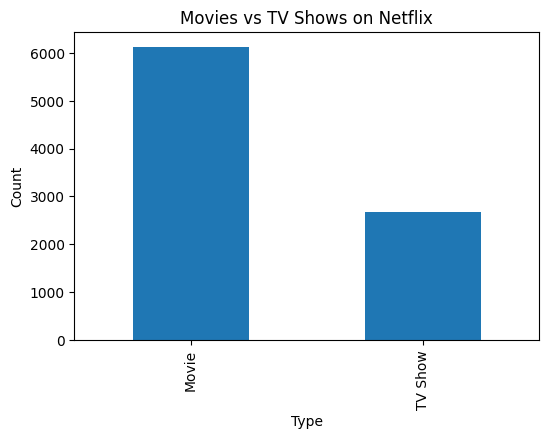

In [50]:
plt.figure(figsize=(6,4))

df['type'].value_counts().plot(kind='bar')

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

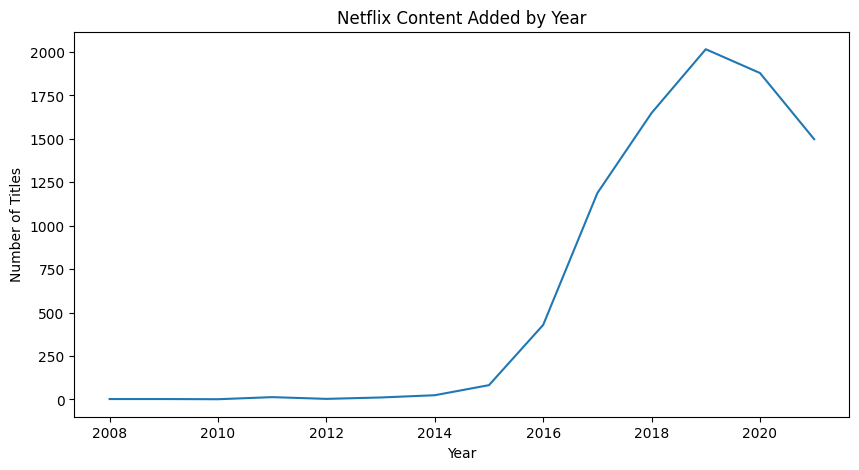

In [51]:
df['year_added'] = df['date_added'].dt.year

plt.figure(figsize=(10,5))

df['year_added'].value_counts().sort_index().plot()

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

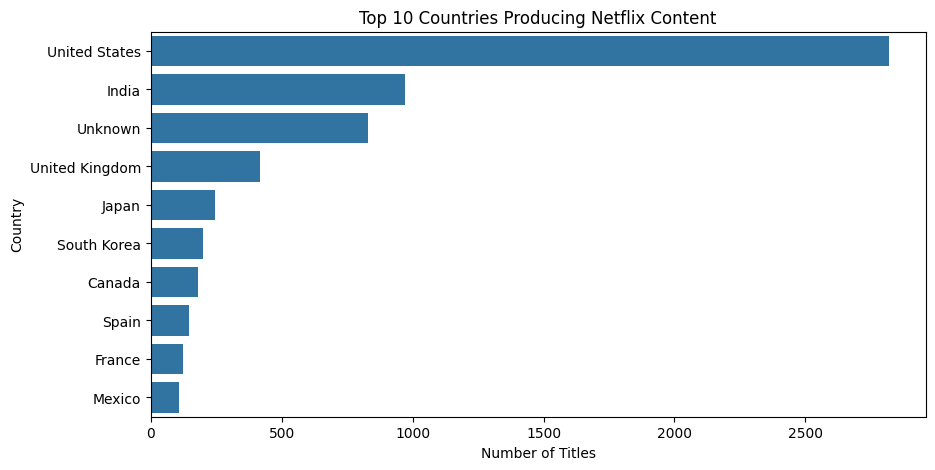

In [52]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

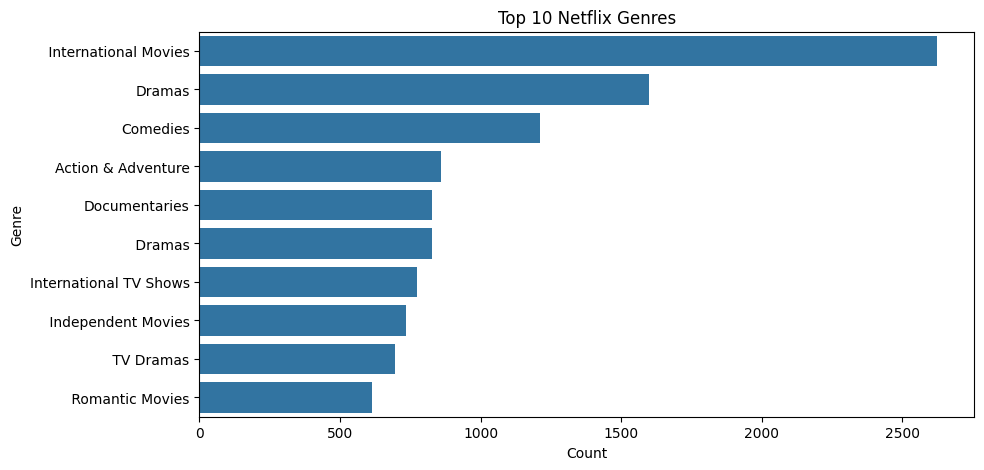

In [53]:
genres = df['listed_in'].str.split(',', expand=True).stack()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

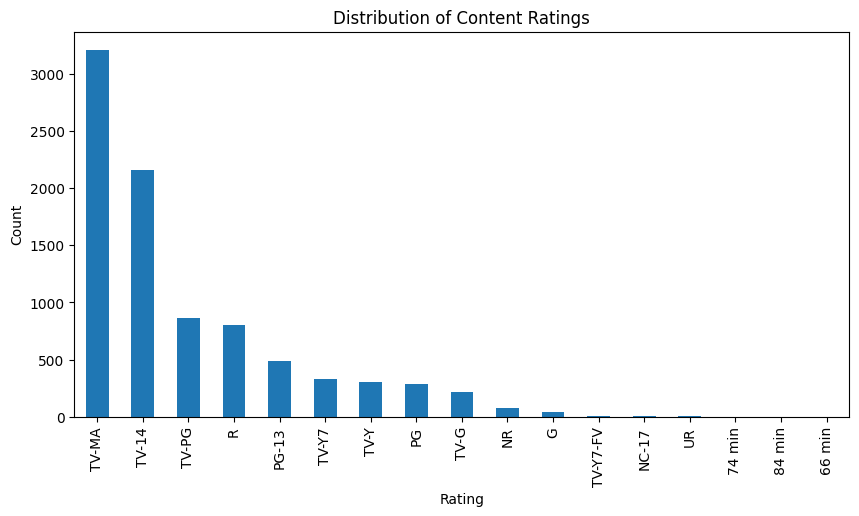

In [54]:
plt.figure(figsize=(10,5))

df['rating'].value_counts().plot(kind='bar')

plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

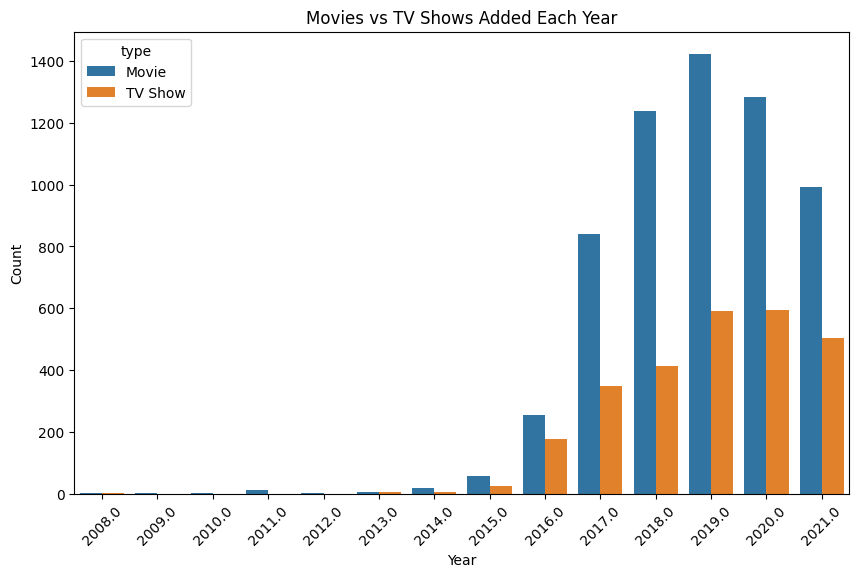

In [55]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x='year_added', hue='type')

plt.title("Movies vs TV Shows Added Each Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [56]:
# Calculate content age
df['content_age'] = 2024 - df['release_year']

df[['title','release_year','content_age']].head()

,title,release_year,content_age
0,Dick Johnson Is Dead,2020,4
1,Blood & Water,2021,3
2,Ganglands,2021,3
3,Jailbirds New Orleans,2021,3
4,Kota Factory,2021,3


In [57]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [58]:
# Encode categorical variables
encoder = LabelEncoder()

df_cluster = df[['type','release_year','content_age']].copy()

df_cluster['type'] = encoder.fit_transform(df_cluster['type'])

df_cluster.head()

,type,release_year,content_age
0,0,2020,4
1,1,2021,3
2,1,2021,3
3,1,2021,3
4,1,2021,3


In [59]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_cluster)

In [60]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(scaled_data)

df[['title','type','release_year','cluster']].head()

,title,type,release_year,cluster
0,Dick Johnson Is Dead,Movie,2020,2
1,Blood & Water,TV Show,2021,0
2,Ganglands,TV Show,2021,0
3,Jailbirds New Orleans,TV Show,2021,0
4,Kota Factory,TV Show,2021,0


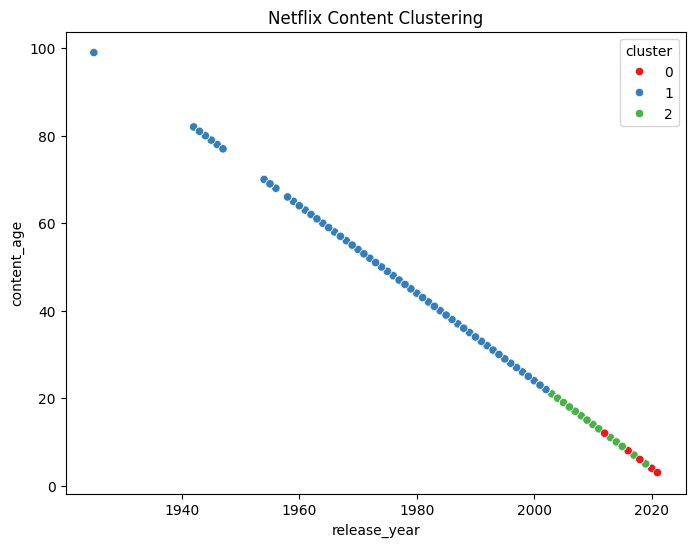

In [61]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="release_year",
    y="content_age",
    hue="cluster",
    palette="Set1"
)

plt.title("Netflix Content Clustering")
plt.show()

In [62]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
import plotly.express as px

In [65]:
pip install nbformat ipython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
pip install nbformat ipython --upgrade

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
import plotly.io as pio
pio.renderers.default = "browser"

In [71]:
import plotly.express as px

type_counts = df['type'].value_counts().reset_index()
type_counts.columns = ['type', 'count']

fig = px.bar(
    type_counts,
    x='type',
    y='count',
    title="Movies vs TV Shows on Netflix",
    labels={'type': 'Type', 'count': 'Count'}
)

fig.show()

In [72]:
fig.show()

In [73]:
pip install streamlit

     ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
     - -------------------------------------- 0.4/9.1 MB 7.4 MB/s eta 0:00:02
     -- ------------------------------------- 0.6/9.1 MB 6.3 MB/s eta 0:00:02
     --- ------------------------------------ 0.8/9.1 MB 6.4 MB/s eta 0:00:02
     --- ------------------------------------ 0.8/9.1 MB 6.4 MB/s eta 0:00:02
     ---- ----------------------------------- 1.0/9.1 MB 4.3 MB/s eta 0:00:02
     ----- ---------------------------------- 1.3/9.1 MB 4.9 MB/s eta 0:00:02
     ------ --------------------------------- 1.5/9.1 MB 5.1 MB/s eta 0:00:02
     -------- ------------------------------- 1.9/9.1 MB 5.3 MB/s eta 0:00:02
     --------- ------------------------------ 2.2/9.1 MB 5.3 MB/s eta 0:00:02
     ---------- ----------------------------- 2.4/9.1 MB 5.4 MB/s eta 0:00:02
     ----------- ---------------------------- 2.7/9.1 MB 5.3 MB/s eta 0:00:02
     ------------ --------------------------- 2.9/9.1 MB 5.4 MB/s eta 0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
